In [86]:
import sys
sys.path.append('../modules')

In [87]:
from bsts import BSTSForCausalInferenceWrapper
from assets_etl import *

import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
ticker2permno = {
    "TSLA": 93436
}

In [98]:
tweets = pd.read_csv("../data/twitter/farouk_tweets.csv")
tweets = tweets.rename(columns={"day": "date"}).convert_dtypes()
tweets["date"] = pd.to_datetime(tweets["date"], format="%Y-%m-%d")

start_date = (tweets.date.min() - pd.DateOffset(31)).strftime("%Y-%m-%d")
end_date   = (tweets.date.max() + pd.DateOffset(31)).strftime("%Y-%m-%d")

In [100]:
tweets[["text", "id"]]

,text,id
0,Next I’m buying Coca-Cola to put the cocaine b...,1519480761749016577
1,I hope that even my worst critics remain on Tw...,1518623997054918657
2,Let’s make Twitter maximum fun!,1519495072802390016
3,🚀💫♥️ Yesss!!! ♥️💫🚀 https://t.co/0T9HzUHuh6,1518677066325053441
4,"Listen, I can’t do miracles ok https://t.co/z7...",1519495982723084290
5,the bird is freed,1585841080431321088
6,Comedy is now legal on Twitter,1586104694421659648
7,https://t.co/rbwbsLA1ZG,1593459801966538755
8,"If I die under mysterious circumstances, it’s ...",1523465632502906880
9,https://t.co/kGncG7Hs3M,1587894226695884800


In [91]:
sent2tweets = {}
for sent, group in tweets.groupby("tweetbert_sentiment"):
    sent2tweets[sent] = group

In [57]:
# load data
# wrds_loader = WRDSLoader(username="farouk_b")
# wrds_loader.download_stock_data(ticker2permno, from_=start_date, to=end_date, save_to="../data/stocks/", close_conn=False)
# wrds_loader.download_rf_data(start_date, end_date, save_to="../data/risk-free/", close_conn=False)
# wrds_loader.download_market_pf_data(start_date, end_date, save_to="../data/factors/", close_conn=False)
# wrds_loader.download_sp500_data(start_date, end_date, save_to="../data/index/", close_conn=False)
# wrds_loader.close()

Loading library list...
Done


## BSTS ANALYSIS ON STOCKS

In [92]:
# process stocks
stocks = {}
stocks["TSLA"] = preprocess_tsla(read_from="../data/stocks/TSLA_2020_2023.csv")
# process risk-free rate
rf_df = preprocess_rf(read_from="../data/risk-free/rf_2020_2023.csv")
# process market portfolio
mkt_df = preprocess_mkt(read_from="../data/factors/market_2020_2023.csv")

In [93]:
pre_effect_lag_window  = 60 # days
post_effect_lag_window = 5  # days

models = {}
for ticker, stock_df in stocks.items():
    data = merge_data(stock_df, rf_df, mkt_df)
    prepared_data = data.drop(columns=["date"]).astype(float)
    
for sent, tweets in sent2tweets.items():
    for _, tweet in tweets.iterrows():
        print(f">>> TWEET ID: {tweet.id}")
        print(f">>> TWEET: {tweet.text}")
        models[tweet.id] = {}
    
        effect_lag = arg_nearest_after(tweet.date, data.date)
        if effect_lag is None:
            print(f"### skipped {tweet.id}")
            continue
        effect_lag = int(effect_lag)
        
        bsts_model = BSTSForCausalInferenceWrapper(data=prepared_data)
        bsts_model.fit(effect_lag, pre_effect_lag_window, post_effect_lag_window)
        
        models[tweet.id][ticker] = bsts_model

>>> TWEET ID: 1518623997054918657
>>> TWEET: I hope that even my worst critics remain on Twitter, because that is what free speech means
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.18035D+00    |proj g|=  2.84803D-01

At iterate    5    f=  1.14597D+00    |proj g|=  2.79828D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      7     20      1     0     0   3.136D-05   1.146D+00
  F =   1.1459712047970501     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH         

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.22252D+00    |proj g|=  1.98979D-01

At iterate    5    f=  1.20956D+00    |proj g|=  1.20306D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      7     10      1     0     0   9.095D-06   1.210D+00
  F =   1.2095635033475682     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
>>> TWEET ID: 1593459801966538755
>>> TWEET: https://t.co/rbwbsLA1ZG
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision 

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.



At iterate    5    f=  1.08357D+00    |proj g|=  1.29765D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      9     14      1     0     0   4.750D-05   1.084D+00
  F =   1.0835214073940773     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
>>> TWEET ID: 1625368108461613057
>>> TWEET: https://t.co/iZUukCVrl5
### skipped 1625368108461613057
>>> TWEET ID: 1519495072802390016
>>> TWEET: Let’s make Twitter maximum fun!
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0

 This problem is unconstrained.
 This problem is unconstrained.
 This problem is unconstrained.


In [101]:
models[1519495982723084290]["TSLA"].summary()

                                  Average         Cumulative
Actual                                  0                  0
Predicted                               0                  0
95% CI                             [0, 0]             [0, 0]
                                                            
Absolute Effect                         0                  0
95% CI                             [0, 0]             [0, 0]
                                                            
Relative Effect                     19.7%              19.7%
95% CI                  [439.8%, -400.3%]  [439.8%, -400.3%]
                                                            
P-value                             32.0%                   
Prob. of Causal Effect              68.0%                   
None


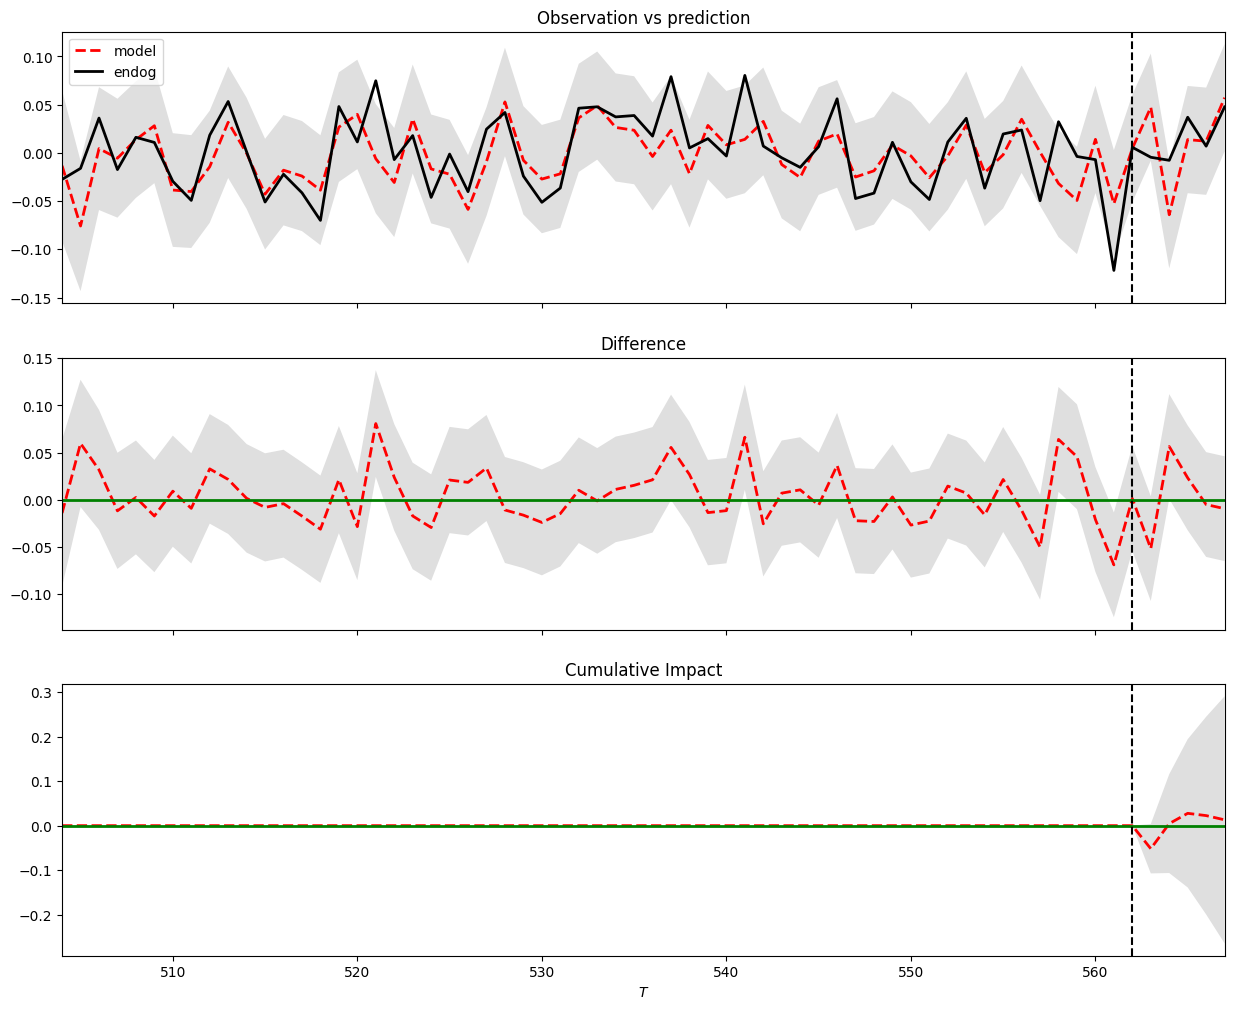

In [102]:
models[1519495982723084290]["TSLA"].plot()